In [1]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Use only two features for easy visualization
y = (iris.target == 1).astype(int)  # Binary classification: Classify as "Iris-Versicolor"
# Convert to DataFrame for better understanding
df = pd.DataFrame(X, columns=["Feature1 (Sepal Length)", "Feature2 (Sepal Width)"])
df["Target"] = y
print("Dataset:")
print(df.head())


Dataset:
   Feature1 (Sepal Length)  Feature2 (Sepal Width)  Target
0                      5.1                     3.5       0
1                      4.9                     3.0       0
2                      4.7                     3.2       0
3                      4.6                     3.1       0
4                      5.0                     3.6       0


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [5]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)
# Predict on test set
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.91      0.81        32
           1       0.40      0.15      0.22        13

    accuracy                           0.69        45
   macro avg       0.56      0.53      0.51        45
weighted avg       0.63      0.69      0.64        45



              precision    recall  f1-score   support

           0       0.72      0.91      0.81        32
           1       0.40      0.15      0.22        13

    accuracy                           0.69        45
   macro avg       0.56      0.53      0.51        45
weighted avg       0.63      0.69      0.64        45



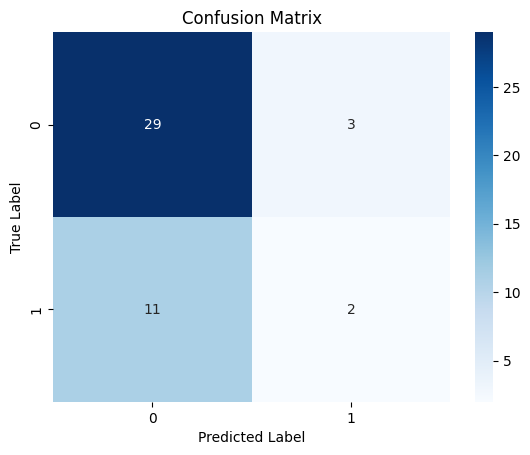

In [6]:
print(classification_report(y_test, y_pred))
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


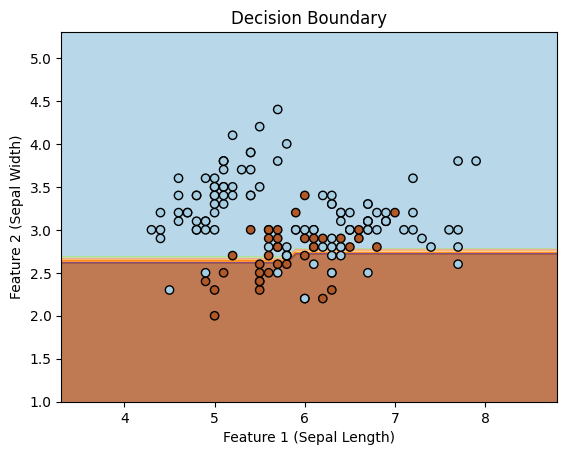

In [7]:
# Visualize decision boundary
import numpy as np
# Generate a grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict on the grid
Z = model.predict(grid).reshape(xx.shape)
# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap="Paired")
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="Paired")
plt.title("Decision Boundary")
plt.xlabel("Feature 1 (Sepal Length)")
plt.ylabel("Feature 2 (Sepal Width)")
plt.show()
